
**Import Important Libraries**





In [383]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.initializers import HeNormal
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import f1_score, classification_report, roc_curve, auc, precision_recall_curve, confusion_matrix
from sklearn.calibration import calibration_curve

%matplotlib inline

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


**Load Dataset**

In [384]:
data_80 = pd.read_csv('churn-bigml-80.csv')
data_20 = pd.read_csv("churn-bigml-20.csv")

df = data_80.copy()
df2 = data_20.copy()

df.head(10)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
5,AL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False
6,MA,121,510,No,Yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False
7,MO,147,415,Yes,No,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False
8,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False
9,RI,74,415,No,No,0,187.7,127,31.91,163.4,148,13.89,196.0,94,8.82,9.1,5,2.46,0,False


## Exploratory Data Analsis - EDA

In [385]:
# Data Quality Audit Table
def audit_table(df):

    rows = []

    for col in df.columns:
        dtype = str(df[col].dtype)
        nulls = df[col].isnull().sum()
        pct_null = nulls / len(df) * 100

        if dtype in ['int64', 'float64']:
            lo, hi = df[col].min(), df[col].max()
            strategy = 'None needed' if nulls == 0 else 'Needed'
        else:
            lo, hi = df[col].nunique(), '-'
            strategy = 'None needed' if nulls == 0 else 'Needed'

        rows.append({'Feature': col, 'Dtype': dtype, 'Min/Uniques': lo,
                     'Max': hi, 'Nulls': nulls, '% Null': f'{pct_null:.1f}%',
                     'Null Strategy': strategy})

    audit = pd.DataFrame(rows)
    print(f'\n=== Data Quality Audit ===')
    print(f'Total nulls: {df.isnull().sum().sum()} | Shape: {df.shape}')
    return audit

audit_train = audit_table(data_80)
print(audit_train.to_string(index=False))


=== Data Quality Audit ===
Total nulls: 0 | Shape: (2666, 20)
               Feature   Dtype  Min/Uniques    Max  Nulls % Null Null Strategy
                 State  object        51.00      -      0   0.0%   None needed
        Account length   int64         1.00    243      0   0.0%   None needed
             Area code   int64       408.00    510      0   0.0%   None needed
    International plan  object         2.00      -      0   0.0%   None needed
       Voice mail plan  object         2.00      -      0   0.0%   None needed
 Number vmail messages   int64         0.00     50      0   0.0%   None needed
     Total day minutes float64         0.00  350.8      0   0.0%   None needed
       Total day calls   int64         0.00    160      0   0.0%   None needed
      Total day charge float64         0.00  59.64      0   0.0%   None needed
     Total eve minutes float64         0.00  363.7      0   0.0%   None needed
       Total eve calls   int64         0.00    170      0   0.0%   N

In [386]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [387]:
df.describe(include='O')

,State,International plan,Voice mail plan
count,2666,2666,2666
unique,51,2,2
top,WV,No,No
freq,88,2396,1933


In [388]:
# Target class values

df.Churn.value_counts()

,count
Churn,
False,2278
True,388


In [389]:
# % of class values
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
False,85.446362
True,14.553638


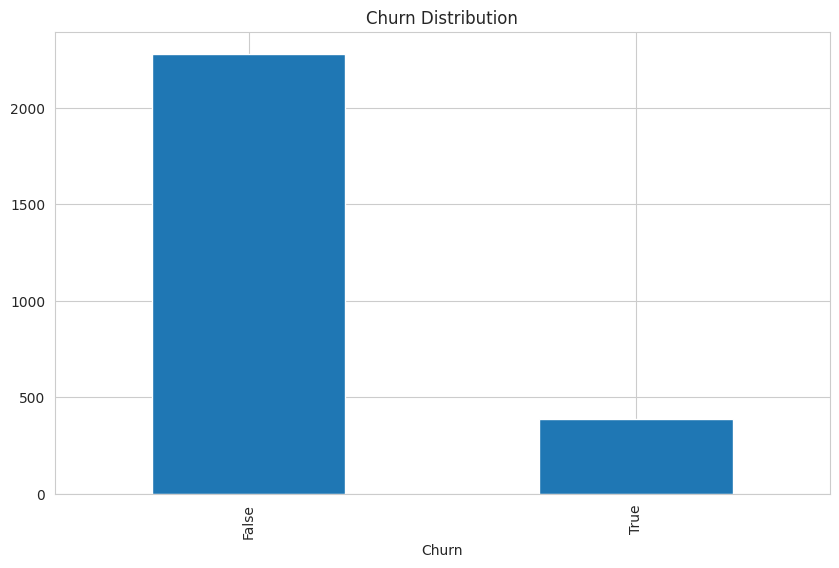

In [390]:
# Target Distribution
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.show()

In [391]:
# Compare Churn vs Non-Churn Using Mean
df.groupby('Churn').mean(numeric_only=True)

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
Churn,,,,,,,,,,,,,,,,
False,100.330992,437.420983,8.507463,175.104346,100.159350,29.768266,198.853380,100.036435,16.902809,200.464091,100.007902,9.020975,10.13784,4.538191,2.737709,1.453029
True,102.319588,437.543814,5.170103,205.181186,101.195876,34.881340,209.385309,99.948454,17.797861,205.307216,100.682990,9.238892,10.81933,4.051546,2.921727,2.206186


In [392]:
# Usage Analysis in minutes
features = [
    'Total day minutes', 'Total eve minutes',
    'Total night minutes', 'Total intl minutes'
]

df.groupby('Churn')[features].mean()

,Total day minutes,Total eve minutes,Total night minutes,Total intl minutes
Churn,,,,
False,175.104346,198.853380,200.464091,10.13784
True,205.181186,209.385309,205.307216,10.81933


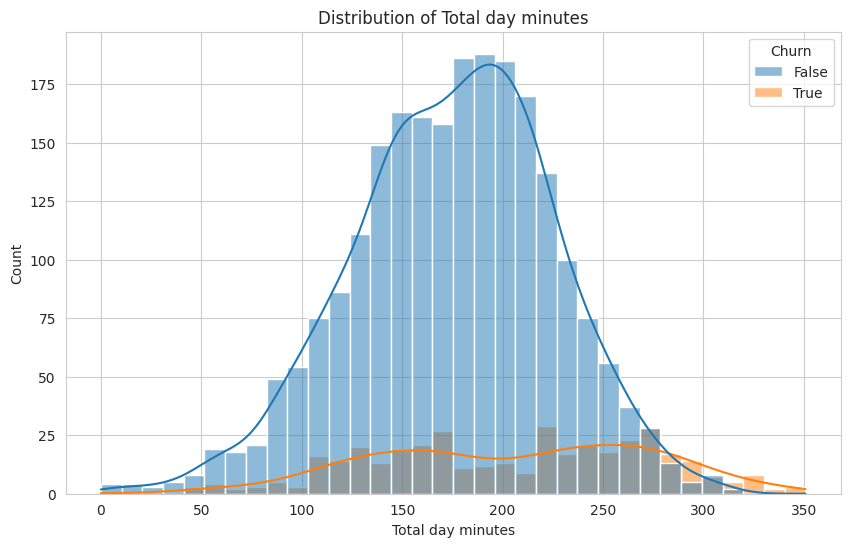

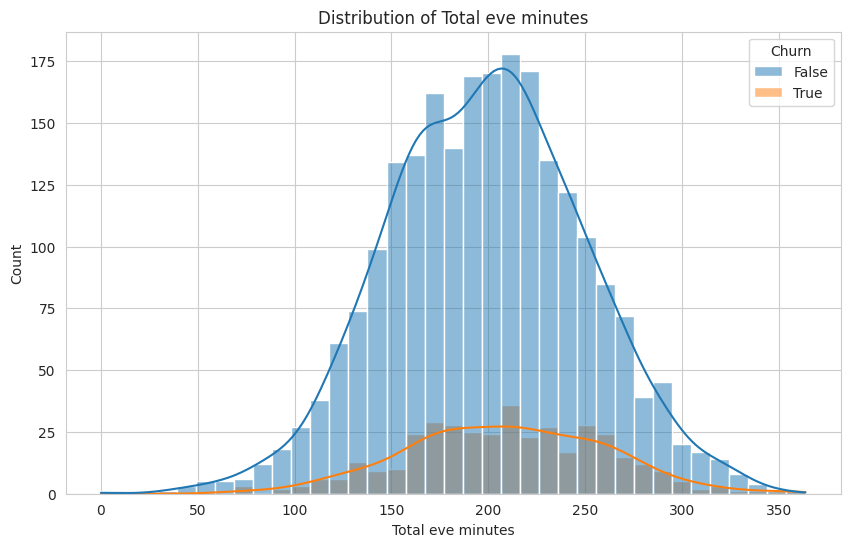

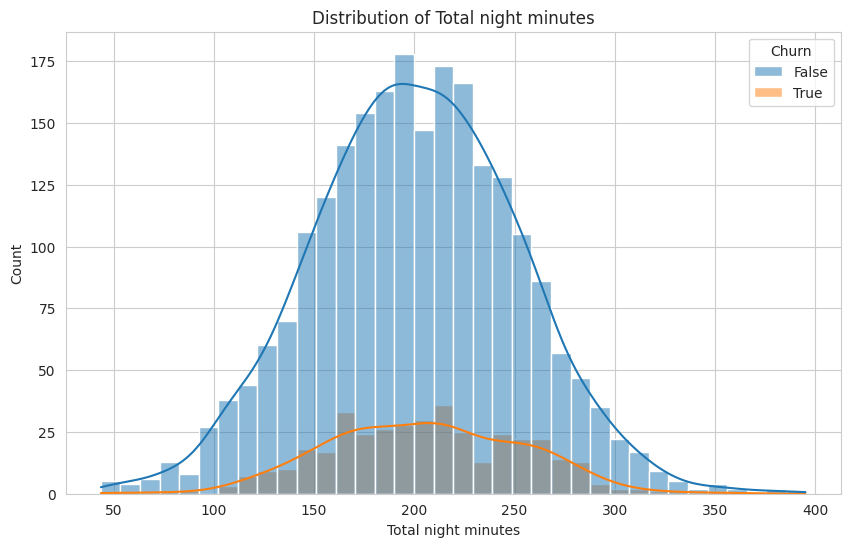

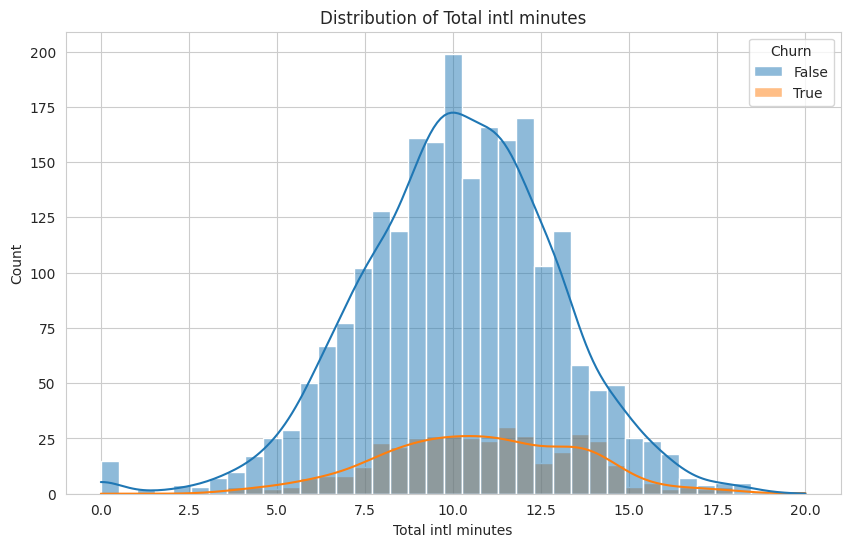

In [393]:
# Distribution Plots for Usage Features (Minutes)
for col in features:
    plt.figure()
    sns.histplot(data=df, x=col, hue='Churn', kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [394]:
df.groupby('Churn')['Customer service calls'].mean()

,Customer service calls
Churn,
False,1.453029
True,2.206186


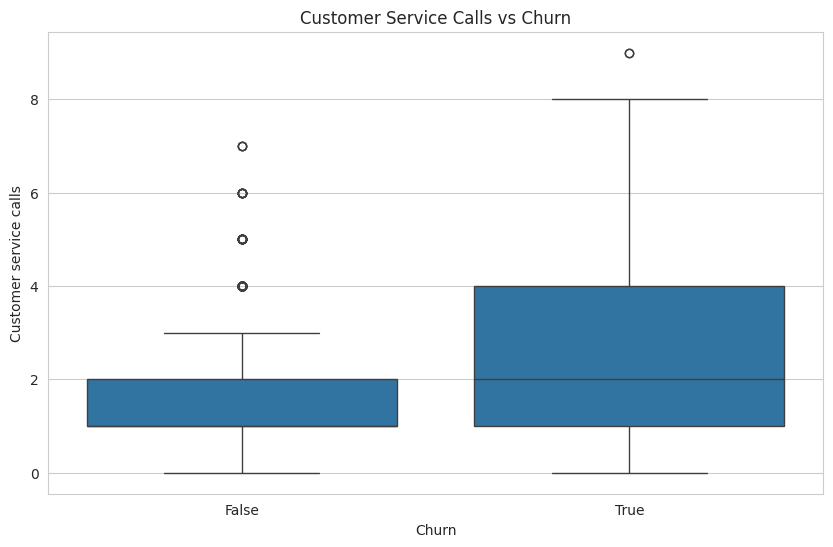

In [395]:
sns.boxplot(x='Churn', y='Customer service calls', data=df)
plt.title("Customer Service Calls vs Churn")
plt.show()

In [396]:
# International plan impact
pd.crosstab(df['International plan'], df['Churn'], normalize='index') * 100

Churn,False,True
International plan,,
No,88.731219,11.268781
Yes,56.296296,43.703704


In [397]:
# Voice mail plan impact
pd.crosstab(df['Voice mail plan'], df['Churn'], normalize='index') * 100

Churn,False,True
Voice mail plan,,
No,83.290222,16.709778
Yes,91.132333,8.867667


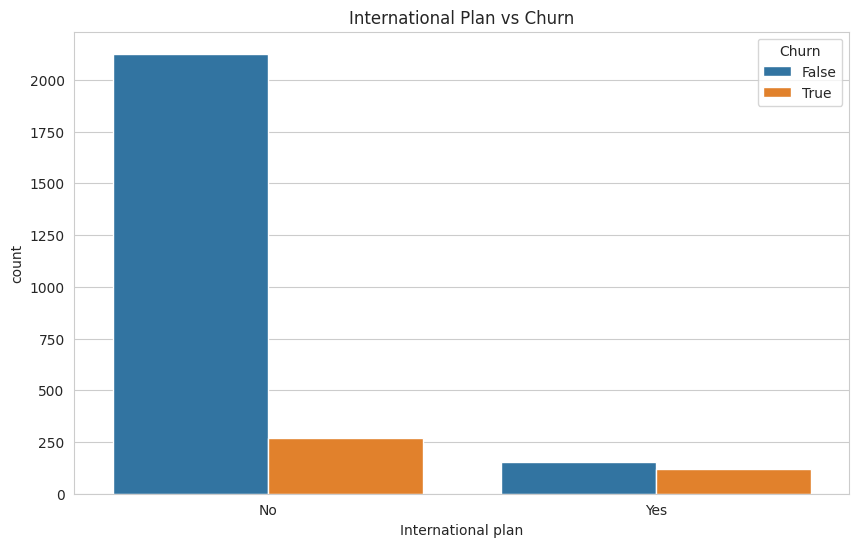

In [398]:
sns.countplot(x='International plan', hue='Churn', data=df)
plt.title("International Plan vs Churn")
plt.show()

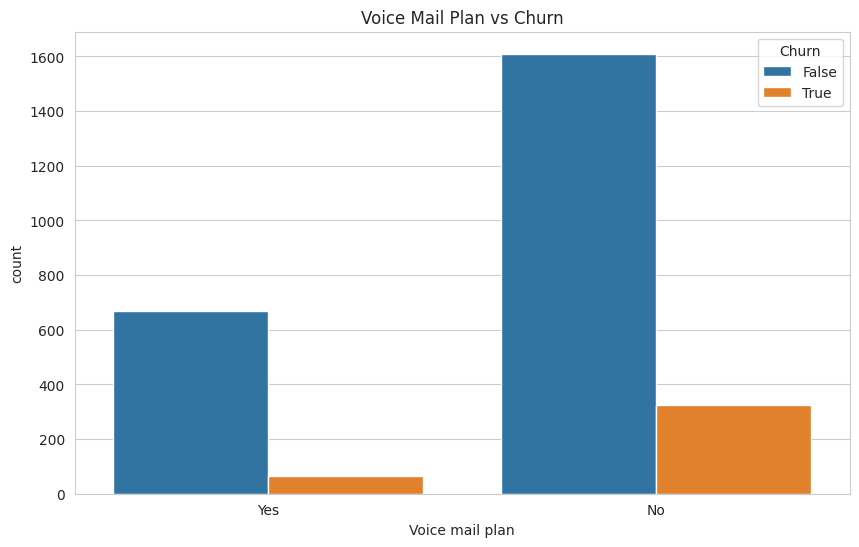

In [399]:
sns.countplot(x='Voice mail plan', hue='Churn', data=df)
plt.title("Voice Mail Plan vs Churn")
plt.show()

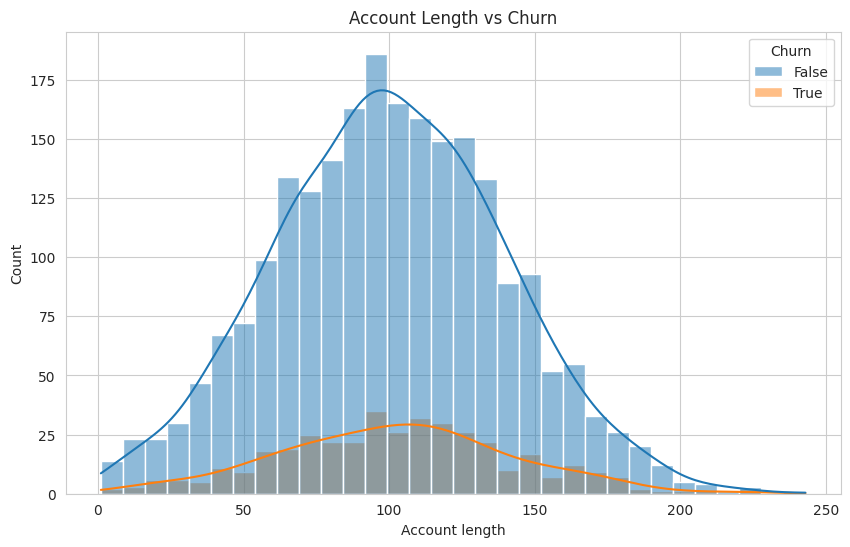

In [400]:
# Account Length vs Churn Inshight
sns.histplot(data=df, x='Account length', hue='Churn', kde=True)
plt.title("Account Length vs Churn")
plt.show()

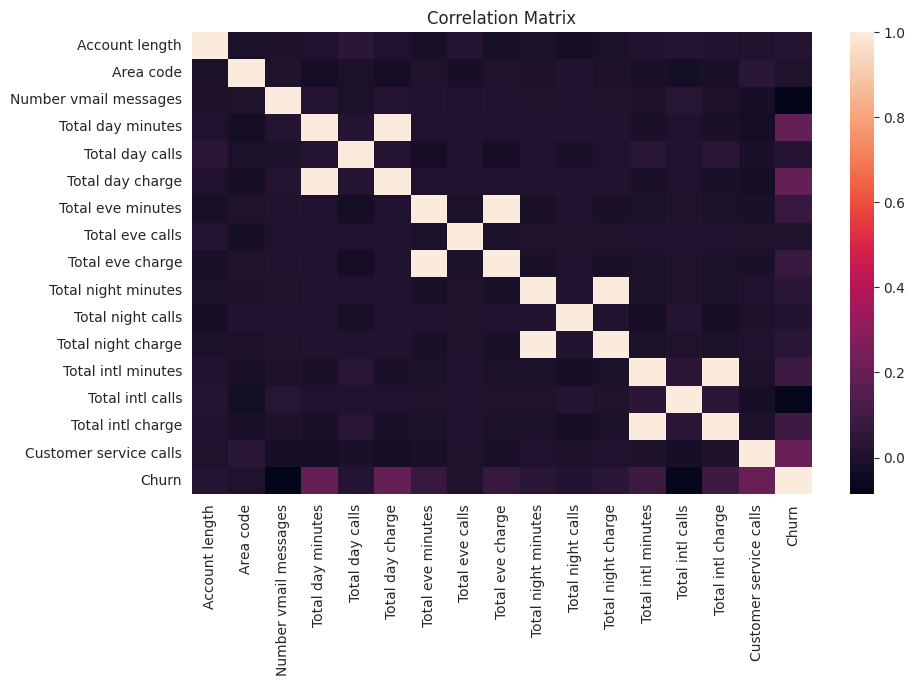

In [401]:
# Correlation Matrix

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Matrix")
plt.show()

EDA Summary:

• Class imbalance: 85.4% No-Churn vs 14.6% Churn → requires imbalance handling.

• 0 null values in both train and test sets → no imputation needed.

• High day minutes/charges correlate strongly with churn.

• Customer service calls ≥ 4 → dramatic churn spike.

• International plan subscribers churn at higher rate.

• There are some of numerical features that are very correlated. So we only have to select one of them and drop the other. → will drop charges to avoid multicollinearity.

• State/Area is not that necessary.

# Preprocessing

In [402]:
def preprocess(df_train, df_test):
    train = df_train.copy()
    test  = df_test.copy()

    # FEATURE ENGINEERING
    def add_features(df):
        df['total_minutes'] = (
            df['Total day minutes'] +
            df['Total eve minutes'] +
            df['Total night minutes'] +
            df['Total intl minutes']
        )

        df['total_calls'] = (
            df['Total day calls'] +
            df['Total eve calls'] +
            df['Total night calls'] +
            df['Total intl calls']
        )

        df['avg_call_duration'] = df['total_minutes'] / (df['total_calls'] + 1)

        df['calls_per_day'] = df['total_calls'] / (df['Account length'] + 1)

        df['intl_ratio'] = df['Total intl minutes'] / (df['total_minutes'] + 1)

        df['high_service_calls'] = (df['Customer service calls'] > 3).astype(int)

        df['zero_intl_usage'] = (df['Total intl minutes'] == 0).astype(int)

        return df

    train = add_features(train)
    test  = add_features(test)

    # DROP COLUMNS
    drop_cols = [
        'Total day charge', 'Total eve charge',
        'Total night charge', 'Total intl charge',
        'State', 'Area code'
    ]

    train.drop(columns=drop_cols, inplace=True, errors='ignore')
    test.drop(columns=drop_cols, inplace=True, errors='ignore')

    # BINARY ENCODING
    for col in ['International plan', 'Voice mail plan']:
        train[col] = (train[col] == 'Yes').astype(int)
        test[col]  = (test[col]  == 'Yes').astype(int)

    # TARGET
    y_train = train.pop('Churn').astype(int).values
    y_test  = test.pop('Churn').astype(int).values

    # SCALING
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train.values)
    X_test  = scaler.transform(test.values)

    feature_names = train.columns.tolist()

    return X_train, y_train, X_test, y_test, scaler, feature_names

# RUN PIPELINE
X_train, y_train, X_test, y_test, scaler, feature_names = preprocess(data_80, data_20)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'Features ({len(feature_names)}): {feature_names}')
print(f'Train class balance: {np.bincount(y_train)}')
print(f'Test  class balance: {np.bincount(y_test)}')

X_train: (2666, 20)  y_train: (2666,)
X_test:  (667, 20)   y_test:  (667,)
Features (20): ['Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls', 'total_minutes', 'total_calls', 'avg_call_duration', 'calls_per_day', 'intl_ratio', 'high_service_calls', 'zero_intl_usage']
Train class balance: [2278  388]
Test  class balance: [572  95]


# Modelling

In [403]:
def build_model(layers_cfg, input_dim, activation='relu', optimizer='adam'):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for units in layers_cfg:
        model.add(layers.Dense(units, activation=activation))

    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [404]:
def train_model(model, X_train, y_train, epochs=50, batch=64, val_split=0.15, verbose=0):
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch,
                        validation_split=val_split, verbose=verbose)
    return history

In [405]:
def plot_learning_curves(histories, labels):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#B07AA1']

    for i, (h, lbl) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]

        axes[0].plot(h.history['loss'], color=c, linewidth=2, label=f'{lbl} train')
        axes[0].plot(h.history['val_loss'], color=c, linestyle='--', linewidth=2, label=f'{lbl} val')

        axes[1].plot(h.history['accuracy'], color=c, linewidth=2, label=f'{lbl} train')
        axes[1].plot(h.history['val_accuracy'], color=c, linestyle='--', linewidth=2, label=f'{lbl} val')

    for ax, title in zip(axes, ['Loss', 'Accuracy']):
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.set_xlabel('Epoch')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [406]:
input_dim = X_train.shape[1]

# A: Shallow Wide -> (1 layer, 128 units, ReLU)
modelA = build_model([128], input_dim)
print('Variant A: Shallow Wide')
modelA.summary()
hist_A = train_model(modelA, X_train, y_train)

Variant A: Shallow Wide


Model: "sequential_105"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_390 (Dense)               │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_391 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [407]:
# B: Deep Narrow -> (4 layers, 32 units, ReLU)
modelB = build_model([32, 32, 32, 32], input_dim)
print('Variant B: Deep Narrow')
modelB.summary()
hist_B = train_model(modelB, X_train, y_train)

Variant B: Deep Narrow


Model: "sequential_106"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_392 (Dense)               │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_393 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_394 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_395 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_396 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,873 (15.13 KB)

 Trainable params: 3,873 (15.13 KB)

 Non-trainable params: 0 (0.00 B)

In [408]:
# C1: tanh activation
modelC1 = build_model([64, 64], input_dim, activation='tanh')
print('Variant C1: tanh')
modelC1.summary()
hist_C1 = train_model(modelC1, X_train, y_train)

Variant C1: tanh


Model: "sequential_107"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_397 (Dense)               │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_398 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_399 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

In [409]:
# C2: LeakyReLU
def build_leaky(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64), layers.LeakyReLU(negative_slope=0.1),
        layers.Dense(64), layers.LeakyReLU(negative_slope=0.1),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

modelC2 = build_leaky(input_dim)
print('Variant C2: LeakyReLU')
modelC2.summary()
hist_C2 = train_model(modelC2, X_train, y_train)

Variant C2: LeakyReLU


Model: "sequential_108"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_400 (Dense)               │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_401 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_402 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

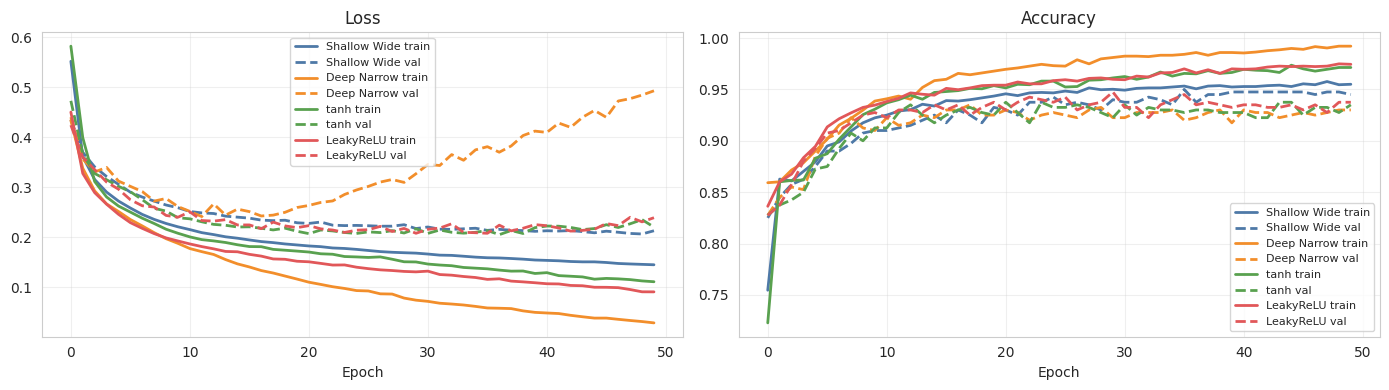

In [410]:
plot_learning_curves([hist_A, hist_B, hist_C1, hist_C2], ['Shallow Wide', 'Deep Narrow', 'tanh', 'LeakyReLU'])

In [411]:
print('Parameter Counts:')
for name, m in [('Shallow Wide', modelA), ('Deep Narrow', modelB),('tanh', modelC1), ('LeakyReLU', modelC2)]:
    print(f'  {name}: {m.count_params():,} parameters')

Parameter Counts:
  Shallow Wide: 2,817 parameters
  Deep Narrow: 3,873 parameters
  tanh: 5,569 parameters
  LeakyReLU: 5,569 parameters


In [412]:
def build_regularized(input_dim, optimizer='adam', init='glorot_uniform'):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu', kernel_initializer=init),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy',
                   metrics=['accuracy',
        tf.keras.metrics.AUC(name='auc')
    ])
    return model

In [413]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

# Optimizers Comparison

opt_results = {}

for opt_name in ['adam', 'sgd', 'rmsprop']:
    print(f'\nRunning optimizer: {opt_name}')

    m = build_regularized(input_dim, optimizer=opt_name)

    h = m.fit(
        X_train, y_train,
        epochs=80,
        batch_size=64,
        validation_split=0.15,
        callbacks=callbacks,
        verbose=0
    )

    # Best AUC
    best_auc = max(h.history['val_auc'])
    best_epoch = np.argmax(h.history['val_auc']) + 1

    opt_results[opt_name] = (h, best_auc)

    print(f'{opt_name:10s} - best val_auc: {best_auc:.4f} (epoch {best_epoch})')


Running optimizer: adam

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 36: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 41: early stopping
Restoring model weights from the end of the best epoch: 31.
adam       - best val_auc: 0.9144 (epoch 30)

Running optimizer: sgd

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
sgd        - best val_auc: 0.8481 (epoch 10)

Running optimizer: rmsprop

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
rmsprop    - best val_auc: 0.9192 (ep

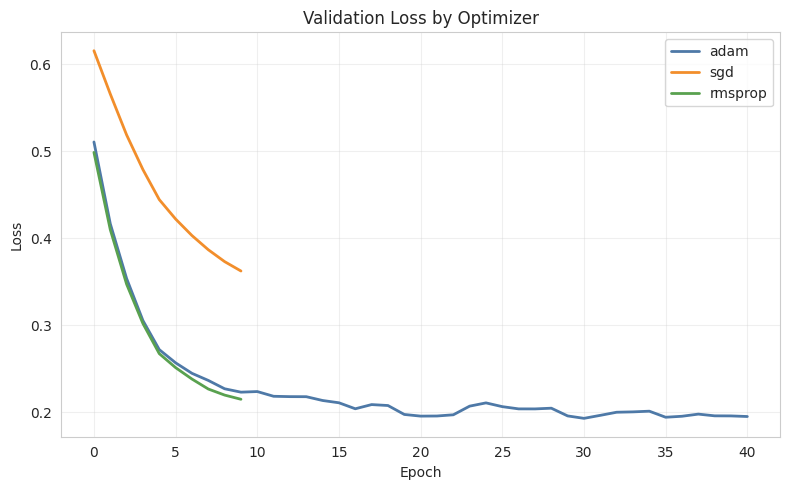

In [414]:
plt.figure(figsize=(8,5))

colors = {
    'adam':    '#4E79A7',
    'sgd':     '#F28E2B',
    'rmsprop': '#59A14F'
}

for opt_name, (h, _) in opt_results.items():
    c = colors.get(opt_name, '#333333')

    plt.plot(h.history['val_loss'],
             color=c, linewidth=2, label=opt_name)

plt.title('Validation Loss by Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

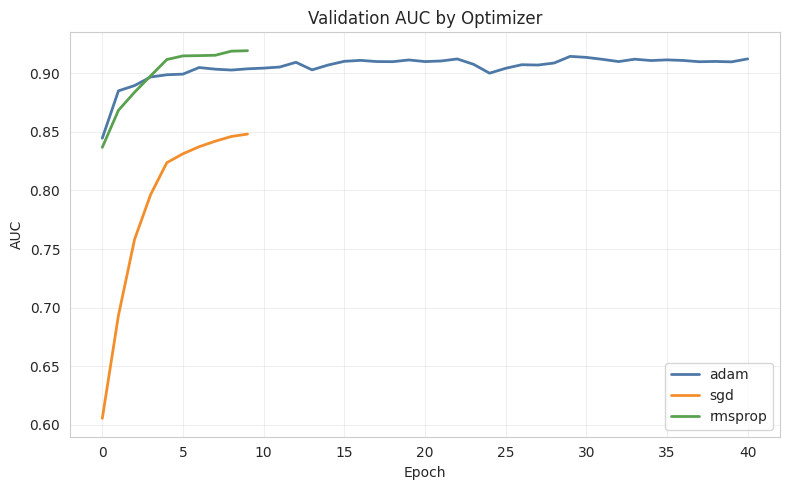

In [415]:
plt.figure(figsize=(8,5))

colors = {
    'adam':    '#4E79A7',
    'sgd':     '#F28E2B',
    'rmsprop': '#59A14F'
}

for opt_name, (h, _) in opt_results.items():
    c = colors.get(opt_name, '#333333')

    plt.plot(h.history['val_auc'],
             color=c, linewidth=2, label=opt_name)

plt.title('Validation AUC by Optimizer')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [416]:
init_results = {}

for init_name in ['glorot_uniform', 'he_normal', 'random_normal']:

    print(f'\nRunning initialization: {init_name}')

    m = build_regularized(input_dim, init=init_name)

    h = m.fit(
        X_train, y_train,
        epochs=80,
        batch_size=64,
        validation_split=0.15,
        callbacks=callbacks,
        verbose=0
    )

    # AUC
    best_auc = max(h.history['val_auc'])
    best_epoch = np.argmax(h.history['val_auc']) + 1

    init_results[init_name] = (h, best_auc)

    print(f'{init_name:18s} - best val_auc: {best_auc:.4f} (epoch {best_epoch})')


Running initialization: glorot_uniform

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
glorot_uniform     - best val_auc: 0.8853 (epoch 9)

Running initialization: he_normal

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
he_normal          - best val_auc: 0.9066 (epoch 10)

Running initialization: random_normal

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
random_normal      - best val_auc: 0.9222 (epoch 10)


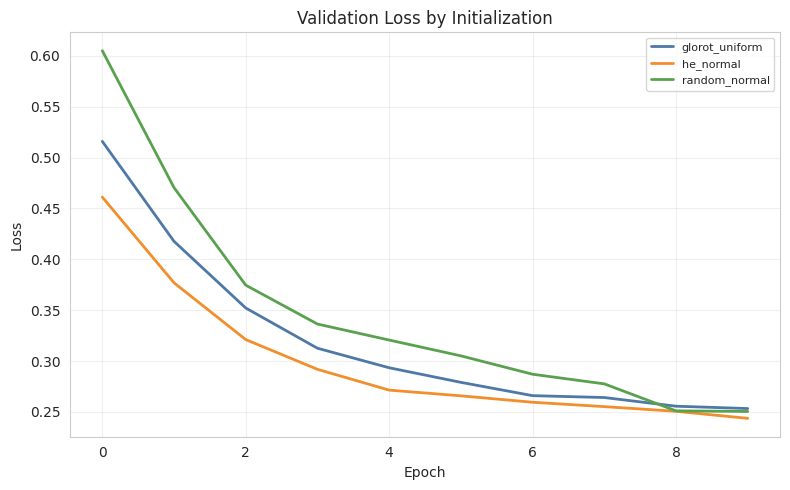

In [417]:
plt.figure(figsize=(8,5))

colors2 = {
    'glorot_uniform': '#4E79A7',
    'he_normal':      '#F28E2B',
    'random_normal':  '#59A14F'
}

for name, (h, _) in init_results.items():
    c = colors2.get(name, '#333333')

    plt.plot(h.history['val_loss'],
             color=c, linewidth=2, label=name)

plt.title('Validation Loss by Initialization')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

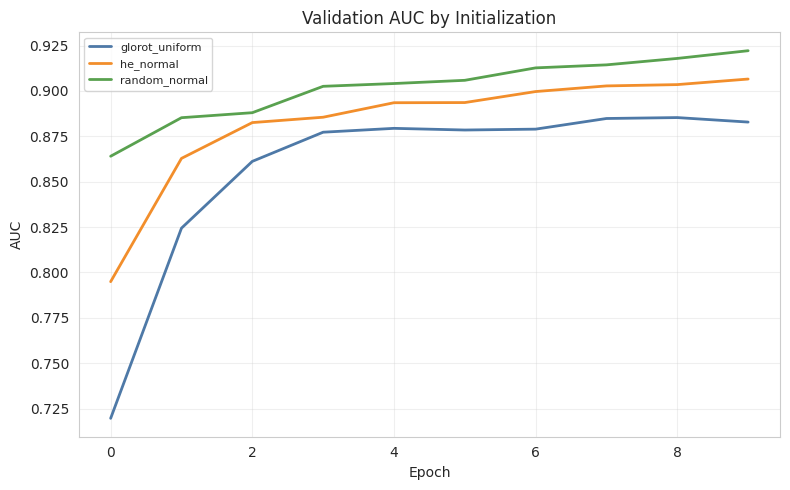

In [418]:
plt.figure(figsize=(8,5))

colors2 = {
    'glorot_uniform': '#4E79A7',
    'he_normal':      '#F28E2B',
    'random_normal':  '#59A14F'
}

for name, (h, _) in init_results.items():
    c = colors2.get(name, '#333333')

    plt.plot(h.history['val_auc'],
             color=c, linewidth=2, label=name)

plt.title('Validation AUC by Initialization')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [419]:
baseline_acc = 1 - y_test.mean()
print(f'"Always No-Churn" baseline acc: {baseline_acc:.4f}')

"Always No-Churn" baseline acc: 0.8576


In [420]:
class_w = compute_class_weight('balanced', classes = np.array([0, 1]), y = y_train)
class_weight_dict = {0: class_w[0], 1: class_w[1]}
print('Class weights:', class_weight_dict)

Class weights: {0: np.float64(0.5851624231782265), 1: np.float64(3.435567010309278)}


In [421]:
model_classw = build_regularized(input_dim)
hist_classw = model_classw.fit(X_train, y_train, epochs=80, batch_size=64,
                    validation_split=0.15, class_weight=class_weight_dict,
                    callbacks=callbacks, verbose=0)


Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.


In [422]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

unique, counts = np.unique(y_smote, return_counts=True)

print("After SMOTE class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt}")

After SMOTE class distribution:
Class 0: 2278
Class 1: 2278


In [423]:
model_smote = build_regularized(input_dim)
hist_smote = model_smote.fit(X_sm, y_sm, epochs=80, batch_size=64,
                          validation_split=0.15, callbacks=callbacks, verbose=0)


Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.


In [424]:
y_prob_classw = model_cw.predict(X_test).flatten()

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_classw)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_idx  = np.argmax(f1_scores)
best_thr  = thresholds[best_idx]

print(f"\nOptimal threshold: {best_thr:.3f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Optimal threshold: 0.591


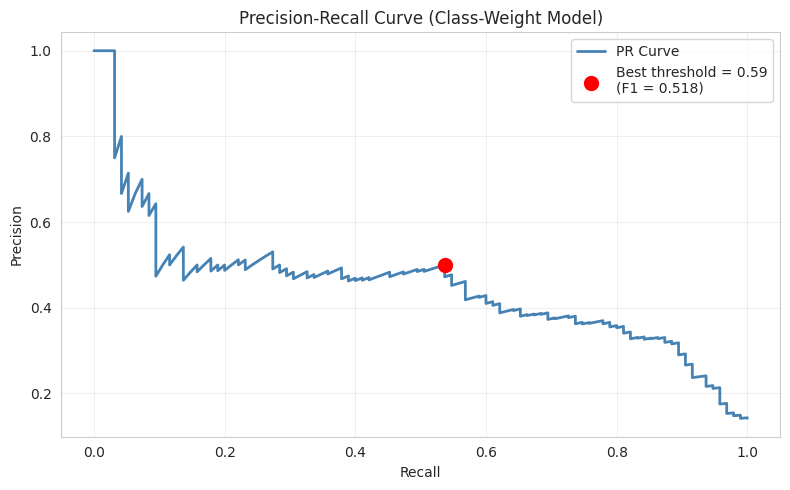

In [425]:
plt.figure(figsize=(8, 5))

plt.plot(recall, precision, color='steelblue', lw=2, label='PR Curve')

plt.scatter(recall[best_idx], precision[best_idx],
            color='red', s=100, zorder=5,
            label=f'Best threshold = {best_thr:.2f}\n(F1 = {f1_scores[best_idx]:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Class-Weight Model)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [426]:
y_prob_smote = model_smote.predict(X_test).flatten()

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [427]:
models_eval = {
    'Class Weights': (model_classw,    y_prob_classw,    best_thr),
    'SMOTE':         (model_smote, y_prob_smote, best_thr),
}

for name, (m, probs, thr) in models_eval.items():
    preds = (probs >= thr).astype(int)
    print(f'\n{'='*50}')
    print(f' Model: {name}  (threshold={thr:.2f})')
    print('='*50)
    print(classification_report(y_test, preds, target_names=['No Churn','Churn']))
    print(f'ROC-AUC: {roc_auc_score(y_test, probs):.4f}')


 Model: Class Weights  (threshold=0.59)
              precision    recall  f1-score   support

    No Churn       0.92      0.91      0.92       572
       Churn       0.50      0.54      0.52        95

    accuracy                           0.86       667
   macro avg       0.71      0.72      0.72       667
weighted avg       0.86      0.86      0.86       667

ROC-AUC: 0.8343

 Model: SMOTE  (threshold=0.59)
              precision    recall  f1-score   support

    No Churn       0.95      0.90      0.93       572
       Churn       0.55      0.71      0.62        95

    accuracy                           0.88       667
   macro avg       0.75      0.80      0.77       667
weighted avg       0.89      0.88      0.88       667

ROC-AUC: 0.8805


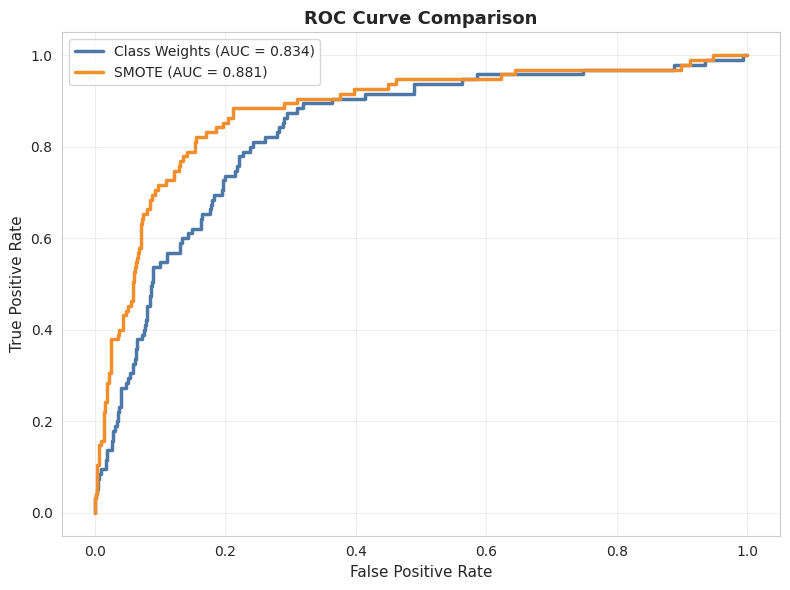

In [428]:
plt.figure(figsize=(8, 6))

colors_roc = {
    'Class Weights': '#4E79A7',
    'SMOTE':         '#F28E2B'
}

for name, (m, probs, thr) in models_eval.items():
    c = colors_roc.get(name, '#333333')

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)

    plt.plot(fpr, tpr,
             color=c, linewidth=2.5,
             label=f'{name} (AUC = {auc_score:.3f})')

# Styling
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve Comparison', fontsize=13, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

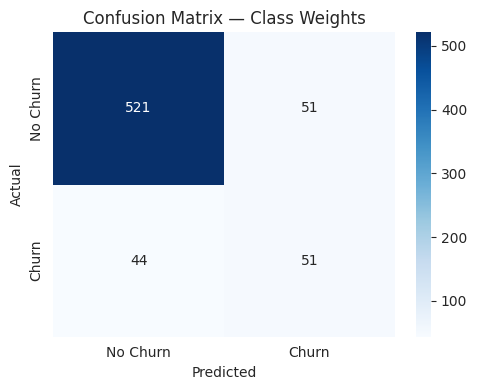

In [429]:
from sklearn.metrics import confusion_matrix

name = 'Class Weights'
m, probs, thr = models_eval[name]

preds = (probs >= thr).astype(int)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])

plt.title(f'Confusion Matrix — {name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

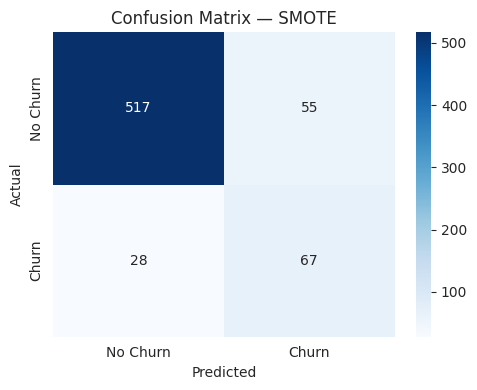

In [430]:
name = 'SMOTE'
m, probs, thr = models_eval[name]

preds = (probs >= thr).astype(int)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])

plt.title(f'Confusion Matrix — {name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

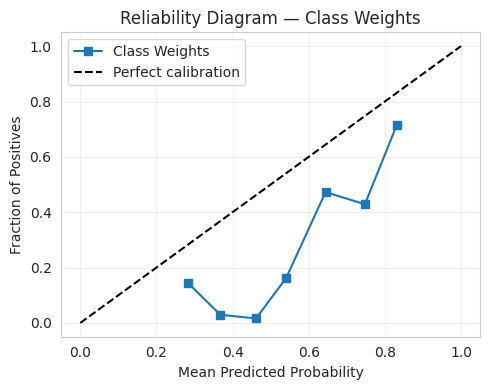

In [431]:
from sklearn.calibration import calibration_curve

name = 'Class Weights'
m, probs, thr = models_eval[name]

fraction_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)

plt.figure(figsize=(5,4))
plt.plot(mean_pred, fraction_pos, 's-', label=name)
plt.plot([0,1],[0,1],'k--', label='Perfect calibration')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title(f'Reliability Diagram — {name}')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

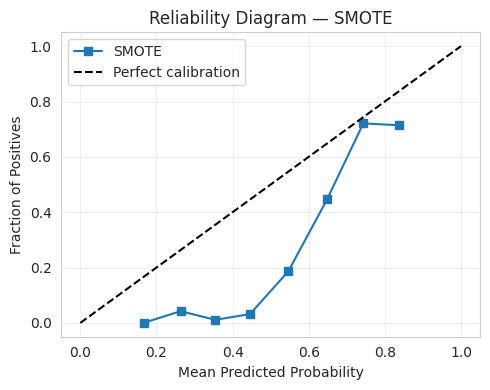

In [432]:
name = 'SMOTE'
m, probs, thr = models_eval[name]

fraction_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)

plt.figure(figsize=(5,4))
plt.plot(mean_pred, fraction_pos, 's-', label=name)
plt.plot([0,1],'k--', label='Perfect calibration')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title(f'Reliability Diagram — {name}')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()